In [1]:
import fastf1
import pandas as pd

fastf1.Cache.enable_cache('./cache')

#### Pull session data

In [2]:
years = [2022, 2023, 2024, 2025]

all_races = {}
for year in years:
    schedule = fastf1.get_event_schedule(year)
    races = list(schedule['EventName'].unique())
    all_races[year] = races

print(all_races)

{2022: ['Pre-Season Track Session', 'Pre-Season Test', 'Bahrain Grand Prix', 'Saudi Arabian Grand Prix', 'Australian Grand Prix', 'Emilia Romagna Grand Prix', 'Miami Grand Prix', 'Spanish Grand Prix', 'Monaco Grand Prix', 'Azerbaijan Grand Prix', 'Canadian Grand Prix', 'British Grand Prix', 'Austrian Grand Prix', 'French Grand Prix', 'Hungarian Grand Prix', 'Belgian Grand Prix', 'Dutch Grand Prix', 'Italian Grand Prix', 'Singapore Grand Prix', 'Japanese Grand Prix', 'United States Grand Prix', 'Mexico City Grand Prix', 'São Paulo Grand Prix', 'Abu Dhabi Grand Prix'], 2023: ['Pre-Season Testing', 'Bahrain Grand Prix', 'Saudi Arabian Grand Prix', 'Australian Grand Prix', 'Azerbaijan Grand Prix', 'Miami Grand Prix', 'Monaco Grand Prix', 'Spanish Grand Prix', 'Canadian Grand Prix', 'Austrian Grand Prix', 'British Grand Prix', 'Hungarian Grand Prix', 'Belgian Grand Prix', 'Dutch Grand Prix', 'Italian Grand Prix', 'Singapore Grand Prix', 'Japanese Grand Prix', 'Qatar Grand Prix', 'United Sta

In [3]:
all_laps = []
failed_races = []
sessions = []

for year in years:
    schedule = fastf1.get_event_schedule(year)
    # Filter to only Grand Prix races (ignore test, pre-season, etc.)
    gp_schedule = schedule[schedule['EventName'].str.contains('Grand Prix', case=False)].copy()
    
    # For 2025, filter to events before June 1, 2025
    if year == 2025:
        gp_schedule['EventDate'] = pd.to_datetime(gp_schedule['EventDate'])
        gp_schedule = gp_schedule[gp_schedule['EventDate'] <= '2025-06-01']
    
    for _, row in gp_schedule.iterrows():
        race_name = row['EventName']
        try:
            session = fastf1.get_session(year, race_name, 'R')
            session.load(laps=True, weather=True, telemetry=True)
            sessions.append(session)
            if hasattr(session, 'laps') and len(session.laps) > 0:
                df = session.laps.copy()
                df['Year'] = year
                df['Race'] = race_name
                all_laps.append(df)
            else:
                failed_races.append((year, race_name))
        except Exception as e:
            failed_races.append((year, race_name))

if all_laps:
    laps_df = pd.concat(all_laps, ignore_index=True)
    print(f"Total laps loaded: {len(laps_df)}")
else:
    print("No lap data loaded.")

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', '18', '23', '3', '4', '6', '27', '11', '1', '10']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info

Total laps loaded: 84522


In [4]:
laps_df.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'Year', 'Race'],
      dtype='object')

In [5]:
laps_df['Year'].value_counts()

Year
2024    26606
2023    24422
2022    23577
2025     9917
Name: count, dtype: int64

In [11]:
laps_df.iloc[20000]

Time                      0 days 01:55:13.511000
Driver                                       PER
DriverNumber                                  11
LapTime                   0 days 00:01:23.023000
LapNumber                                   38.0
Stint                                        2.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:29.091000
Sector2Time               0 days 00:00:32.138000
Sector3Time               0 days 00:00:21.794000
Sector1SessionTime        0 days 01:54:19.585000
Sector2SessionTime        0 days 01:54:51.723000
Sector3SessionTime        0 days 01:55:13.517000
SpeedI1                                    289.0
SpeedI2                                    284.0
SpeedFL                                    245.0
SpeedST                                      NaN
IsPersonalBest                             False
Compound                                  MEDIUM
TyreLife            

#### Add weather and telemetry data

In [13]:
def enrich_with_weather(laps_df, sessions):
    enriched = []

    for session in sessions:
        weather_df = session.weather_data.copy()
        weather_df['Time'] = pd.to_timedelta(weather_df['Time'])  # ensure proper type

        # Match weather per lap
        session_laps = laps_df[
            (laps_df['Year'] == session.date.year) &
            (laps_df['Race'] == session.event['EventName'])
        ].copy()
        session_laps['Time'] = session_laps['LapStartTime'].dt.total_seconds()

        # Convert weather time to seconds to merge
        weather_df['WeatherTime'] = weather_df['Time'].dt.total_seconds()

        # Merge each lap with nearest weather row (on absolute time delta)
        session_laps = pd.merge_asof(
            session_laps.sort_values('Time'),
            weather_df.sort_values('WeatherTime'),
            left_on='Time',
            right_on='WeatherTime',
            direction='nearest',
            tolerance=60  # 1 minute
        )

        enriched.append(session_laps)

    return pd.concat(enriched, ignore_index=True)

In [14]:
weather_enriched_df = enrich_with_weather(laps_df, sessions)

In [15]:
weather_enriched_df.shape

(84522, 42)

In [16]:
weather_enriched_df.columns

Index(['Time_x', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'Year', 'Race', 'Time_y', 'AirTemp',
       'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection',
       'WindSpeed', 'WeatherTime'],
      dtype='object')

In [17]:
def aggregate_telemetry(session, laps_df):
    all_features = []

    # Filter laps for this session year
    session_laps = laps_df[
        (laps_df['Year'] == session.date.year) &
        (laps_df['Race'] == session.event['EventName'])
    ]

    for _, lap_row in session_laps.iterrows():
        try:
            lap = session.laps[
                (session.laps['Driver'] == lap_row['Driver']) &
                (session.laps['LapNumber'] == lap_row['LapNumber'])
            ].iloc[0]

            telemetry = lap.get_car_data().add_distance()

            # Aggregate telemetry stats
            features = {
                'Driver': lap_row['Driver'],
                'LapNumber': lap_row['LapNumber'],
                'Stint': lap_row['Stint'],
                'Year': lap_row['Year'],
                'Race': lap_row['Race'],
                'Speed_Mean': telemetry['Speed'].mean(),
                'Speed_Max': telemetry['Speed'].max(),
                'Speed_Std': telemetry['Speed'].std(),
                'RPM_Mean': telemetry['RPM'].mean(),
                'Throttle_Mean': telemetry['Throttle'].mean(),
                'Throttle_Std': telemetry['Throttle'].std(),
                'Brake_Mean': telemetry['Brake'].mean(),
                'Gear_Mean': telemetry['nGear'].mean(),
                'Distance_Total': telemetry['Distance'].max(),  # for per-segment modelling
                'DRS_active_pct': telemetry['DRS'].mean() if 'DRS' in telemetry else 0
            }

            all_features.append(features)

        except (IndexError, AttributeError, KeyError):
            continue  # Skip if data missing

    return pd.DataFrame(all_features)

In [18]:
# Loop through each session and aggregate telemetry
telemetry_agg_dfs = []
for session in sessions:
    telemetry_agg_dfs.append(aggregate_telemetry(session, laps_df))
    print(f"Aggregated telemetry for {session.event['EventName']} {session.date.year}.")

# Combine telemetry features
telemetry_agg_df = pd.concat(telemetry_agg_dfs, ignore_index=True)

Aggregated telemetry for Bahrain Grand Prix 2022.
Aggregated telemetry for Saudi Arabian Grand Prix 2022.
Aggregated telemetry for Australian Grand Prix 2022.
Aggregated telemetry for Emilia Romagna Grand Prix 2022.
Aggregated telemetry for Miami Grand Prix 2022.
Aggregated telemetry for Spanish Grand Prix 2022.
Aggregated telemetry for Monaco Grand Prix 2022.
Aggregated telemetry for Azerbaijan Grand Prix 2022.
Aggregated telemetry for Canadian Grand Prix 2022.
Aggregated telemetry for British Grand Prix 2022.
Aggregated telemetry for Austrian Grand Prix 2022.
Aggregated telemetry for French Grand Prix 2022.
Aggregated telemetry for Hungarian Grand Prix 2022.
Aggregated telemetry for Belgian Grand Prix 2022.
Aggregated telemetry for Dutch Grand Prix 2022.
Aggregated telemetry for Italian Grand Prix 2022.
Aggregated telemetry for Singapore Grand Prix 2022.
Aggregated telemetry for Japanese Grand Prix 2022.
Aggregated telemetry for United States Grand Prix 2022.
Aggregated telemetry for

In [19]:
telemetry_agg_df.shape

(84522, 15)

In [20]:
telemetry_agg_df.columns

Index(['Driver', 'LapNumber', 'Stint', 'Year', 'Race', 'Speed_Mean',
       'Speed_Max', 'Speed_Std', 'RPM_Mean', 'Throttle_Mean', 'Throttle_Std',
       'Brake_Mean', 'Gear_Mean', 'Distance_Total', 'DRS_active_pct'],
      dtype='object')

In [21]:
# Merge telemetry features into laps+weather
final_df = pd.merge(
    weather_enriched_df,
    telemetry_agg_df,
    on=['Driver', 'LapNumber', 'Stint', 'Year', 'Race'],
    how='inner'
)

In [22]:
# Check for duplicates
final_df.duplicated(subset=['Driver', 'LapNumber', 'Stint', 'Year', 'Race']).any()

np.False_

In [23]:
# Save to csv for later use
final_df.to_csv('data/f1_laps.csv', index=False)

In [24]:
final_df.shape

(84522, 52)

In [25]:
final_df.columns

Index(['Time_x', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'Year', 'Race', 'Time_y', 'AirTemp',
       'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection',
       'WindSpeed', 'WeatherTime', 'Speed_Mean', 'Speed_Max', 'Speed_Std',
       'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
       'Distance_Total', 'DRS_active_pct'],
      dtype='object')

#### Filter columns to keep

In [26]:
# Columns to keep
cols_to_keep = ['Driver', 'Team', 'Year', 'Race',
    'Sector1Time', 'Sector2Time', 'Sector3Time',
    'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
    'SpeedI1', 'SpeedI2', 'SpeedFL',
    'Stint', 'LapTime', 'LapNumber', 'Position',
    'Compound', 'TyreLife', 'FreshTyre', 'TrackStatus',
    'AirTemp', 'Humidity', 'Pressure', 'Rainfall',
    'TrackTemp', 'WindDirection', 'WindSpeed',
    'Speed_Mean', 'Speed_Max', 'Speed_Std', 'RPM_Mean',
    'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
    'Distance_Total', 'DRS_active_pct'
]

In [27]:
filtered_df = final_df[cols_to_keep]

In [28]:
filtered_df.shape

(84522, 38)

In [29]:
filtered_df.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Sector1Time', 'Sector2Time',
       'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime',
       'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'Stint',
       'LapTime', 'LapNumber', 'Position', 'Compound', 'TyreLife', 'FreshTyre',
       'TrackStatus', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall',
       'TrackTemp', 'WindDirection', 'WindSpeed', 'Speed_Mean', 'Speed_Max',
       'Speed_Std', 'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean',
       'Gear_Mean', 'Distance_Total', 'DRS_active_pct'],
      dtype='object')

#### Filter rows to keep

In [30]:
filtered_df.isnull().sum()

Driver                    0
Team                      0
Year                      0
Race                      0
Sector1Time            1791
Sector2Time             157
Sector3Time             269
Sector1SessionTime     1984
Sector2SessionTime      157
Sector3SessionTime      269
SpeedI1               12968
SpeedI2                 177
SpeedFL                3120
Stint                   446
LapTime                1319
LapNumber                 0
Position                123
Compound                  0
TyreLife                446
FreshTyre                 0
TrackStatus               0
AirTemp                   9
Humidity                  9
Pressure                  9
Rainfall                  9
TrackTemp                 9
WindDirection             9
WindSpeed                 9
Speed_Mean                0
Speed_Max                 0
Speed_Std                 0
RPM_Mean                  0
Throttle_Mean             0
Throttle_Std              0
Brake_Mean                0
Gear_Mean           

In [31]:
filtered_df[filtered_df['TyreLife'].isnull()].groupby(['Year', 'Race']).size()

Year  Race            
2025  Miami Grand Prix    446
dtype: int64

In [32]:
filtered_df[(filtered_df['Year']==2025) & (filtered_df['Race']=='Miami Grand Prix')].shape

(1005, 38)

In [33]:
# Remove 2025 Miami Grand Prix
filtered_df = filtered_df[~((filtered_df['Year'] == 2025) & (filtered_df['Race'] == 'Miami Grand Prix'))]

In [34]:
filtered_df.isnull().sum()

Driver                    0
Team                      0
Year                      0
Race                      0
Sector1Time            1769
Sector2Time             154
Sector3Time             266
Sector1SessionTime     1957
Sector2SessionTime      154
Sector3SessionTime      266
SpeedI1               12743
SpeedI2                 174
SpeedFL                3098
Stint                     0
LapTime                1316
LapNumber                 0
Position                120
Compound                  0
TyreLife                  0
FreshTyre                 0
TrackStatus               0
AirTemp                   9
Humidity                  9
Pressure                  9
Rainfall                  9
TrackTemp                 9
WindDirection             9
WindSpeed                 9
Speed_Mean                0
Speed_Max                 0
Speed_Std                 0
RPM_Mean                  0
Throttle_Mean             0
Throttle_Std              0
Brake_Mean                0
Gear_Mean           

In [35]:
filtered_df[filtered_df['LapTime'].isnull()].groupby(['Year', 'Race']).size()

Year  Race                     
2022  Australian Grand Prix        19
      Austrian Grand Prix           1
      Azerbaijan Grand Prix        19
      Bahrain Grand Prix            7
      Belgian Grand Prix           40
                                   ..
2025  Bahrain Grand Prix           14
      Emilia Romagna Grand Prix     2
      Monaco Grand Prix             2
      Saudi Arabian Grand Prix     37
      Spanish Grand Prix            1
Length: 61, dtype: int64

In [36]:
filtered_df[filtered_df['Position'].isnull()].groupby(['Year', 'Race']).size()

Year  Race                     
2022  Australian Grand Prix         3
      Austrian Grand Prix           1
      Azerbaijan Grand Prix         2
      Bahrain Grand Prix            2
      Belgian Grand Prix            2
      British Grand Prix            4
      Canadian Grand Prix           2
      Dutch Grand Prix              1
      Emilia Romagna Grand Prix     1
      French Grand Prix             2
      Hungarian Grand Prix          1
      Italian Grand Prix            2
      Japanese Grand Prix           3
      Mexico City Grand Prix        1
      Miami Grand Prix              1
      Monaco Grand Prix             1
      Saudi Arabian Grand Prix      3
      Singapore Grand Prix          4
      São Paulo Grand Prix          3
      United States Grand Prix      2
2023  Australian Grand Prix         8
      Austrian Grand Prix           1
      Azerbaijan Grand Prix         1
      Bahrain Grand Prix            1
      Belgian Grand Prix            1
      British Gran

In [37]:
weather_cols = ['AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed']
filtered_df[filtered_df[weather_cols].isnull().any(axis=1)][['Driver', 'Race', 'Year', 'LapNumber'] + weather_cols].groupby(['Year', 'Race']).size()

Year  Race              
2023  Italian Grand Prix    9
dtype: int64

In [38]:
mask = (
    (filtered_df['Year'] == 2023) &
    (filtered_df['Race'] == 'Italian Grand Prix') &
    (filtered_df[weather_cols].isnull().any(axis=1))
)

filtered_df.loc[mask, ['Driver', 'LapNumber', 'TyreLife'] + weather_cols]

,Driver,LapNumber,TyreLife,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed
39508,BOT,51.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39509,PIA,51.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39510,LAW,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39511,SAR,51.0,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39512,ZHO,51.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39513,GAS,51.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39514,STR,51.0,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39515,HUL,51.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39516,MAG,51.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Filter out LapTime, Position, Weather data that are null after calculating LapsTilPit.

#### Calculate laps until pit

In [39]:
# Group by Year, Race, Driver, Stint and get min TyreLife per group
filtered_df.groupby(['Year', 'Race', 'Driver', 'Stint'])['TyreLife'].min().sort_values()

Year  Race                       Driver  Stint
2022  Abu Dhabi Grand Prix       ALB     1.0       1.0
2024  Austrian Grand Prix        PIA     1.0       1.0
                                         2.0       1.0
                                         3.0       1.0
                                 RIC     1.0       1.0
                                                  ... 
      Emilia Romagna Grand Prix  ALB     4.0      15.0
2023  Dutch Grand Prix           SAI     5.0      16.0
2024  São Paulo Grand Prix       LAW     2.0      16.0
2025  Spanish Grand Prix         ALB     3.0      21.0
2023  Spanish Grand Prix         LEC     3.0      26.0
Name: TyreLife, Length: 4336, dtype: float64

In [40]:
# Find races without a min TyreLife of 1
min_tyre_life = (
    filtered_df
    .groupby(['Year', 'Race', 'Driver', 'Stint'])['TyreLife']
    .min()
    .reset_index()
)

min_tyre_life[min_tyre_life['TyreLife'] != 1]

,Year,Race,Driver,Stint,TyreLife
39,2022,Abu Dhabi Grand Prix,STR,2.0,2.0
40,2022,Abu Dhabi Grand Prix,STR,3.0,2.0
47,2022,Abu Dhabi Grand Prix,VET,2.0,2.0
63,2022,Australian Grand Prix,LAT,2.0,2.0
68,2022,Australian Grand Prix,MAG,2.0,3.0
...,...,...,...,...,...
4318,2025,Spanish Grand Prix,RUS,1.0,4.0
4321,2025,Spanish Grand Prix,RUS,4.0,4.0
4330,2025,Spanish Grand Prix,TSU,5.0,4.0
4331,2025,Spanish Grand Prix,VER,1.0,4.0


In [41]:
min_tyre_life[min_tyre_life['TyreLife'] != 1]['TyreLife'].value_counts()

TyreLife
4.0     337
2.0     320
3.0     119
5.0      66
6.0      41
7.0      40
8.0      21
9.0      12
10.0      6
13.0      5
12.0      5
11.0      4
16.0      2
14.0      2
26.0      1
15.0      1
21.0      1
Name: count, dtype: int64

These are all scrubbed tires that have been used in previous races.

In [42]:
# Grouping by Year, Race, Driver, Stint,
# LapsTilPit = max(LapNumber in stint) - LapNumber + 1
labelled_df = filtered_df.copy()

labelled_df['LapsTilPit'] = (
    filtered_df.groupby(['Year', 'Race', 'Driver', 'Stint'])['LapNumber']
    .transform(lambda x: x.max() - x + 1)
)

In [43]:
labelled_df.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Sector1Time', 'Sector2Time',
       'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime',
       'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'Stint',
       'LapTime', 'LapNumber', 'Position', 'Compound', 'TyreLife', 'FreshTyre',
       'TrackStatus', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall',
       'TrackTemp', 'WindDirection', 'WindSpeed', 'Speed_Mean', 'Speed_Max',
       'Speed_Std', 'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean',
       'Gear_Mean', 'Distance_Total', 'DRS_active_pct', 'LapsTilPit'],
      dtype='object')

In [44]:
# For a random stint, check LapsTilPit goes from max to 1
sample = labelled_df[
    (labelled_df['Driver'] == 'VER') & 
    (labelled_df['Year'] == 2024) & 
    (labelled_df['Race'] == 'Italian Grand Prix') & 
    (labelled_df['Stint'] == 2)]
print(sample[['LapNumber', 'TyreLife', 'LapsTilPit']])

       LapNumber  TyreLife  LapsTilPit
65548       23.0       1.0        19.0
65573       24.0       2.0        18.0
65590       25.0       3.0        17.0
65609       26.0       4.0        16.0
65628       27.0       5.0        15.0
65647       28.0       6.0        14.0
65666       29.0       7.0        13.0
65685       30.0       8.0        12.0
65704       31.0       9.0        11.0
65723       32.0      10.0        10.0
65742       33.0      11.0         9.0
65760       34.0      12.0         8.0
65779       35.0      13.0         7.0
65798       36.0      14.0         6.0
65817       37.0      15.0         5.0
65836       38.0      16.0         4.0
65853       39.0      17.0         3.0
65872       40.0      18.0         2.0
65891       41.0      19.0         1.0


#### Visualize Label

In [45]:
import matplotlib.pyplot as plt

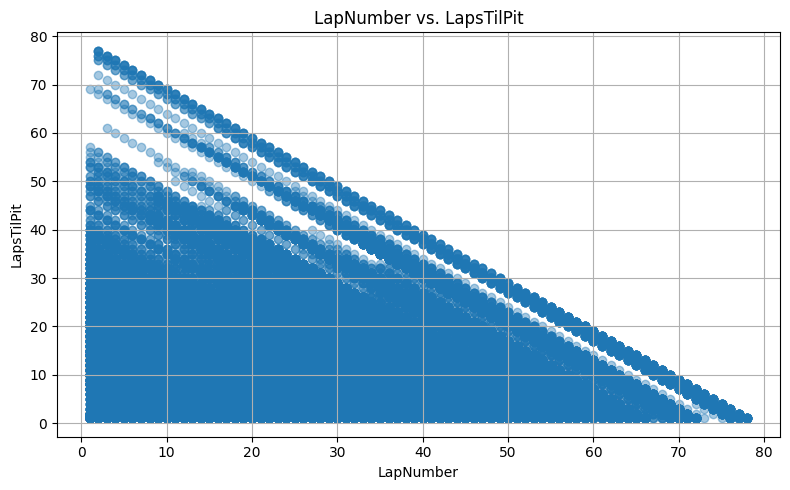

In [46]:
plt.figure(figsize=(8, 5))
plt.scatter(labelled_df['LapNumber'], labelled_df['LapsTilPit'], alpha=0.4)
plt.xlabel('LapNumber')
plt.ylabel('LapsTilPit')
plt.title('LapNumber vs. LapsTilPit')
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

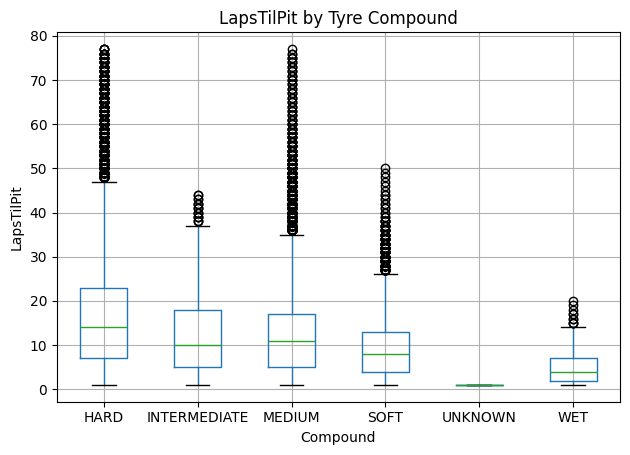

In [47]:
plt.figure(figsize=(8, 5))
labelled_df.boxplot(column='LapsTilPit', by='Compound')
plt.xlabel('Compound')
plt.ylabel('LapsTilPit')
plt.title('LapsTilPit by Tyre Compound')
plt.suptitle('')
plt.tight_layout()
plt.show()

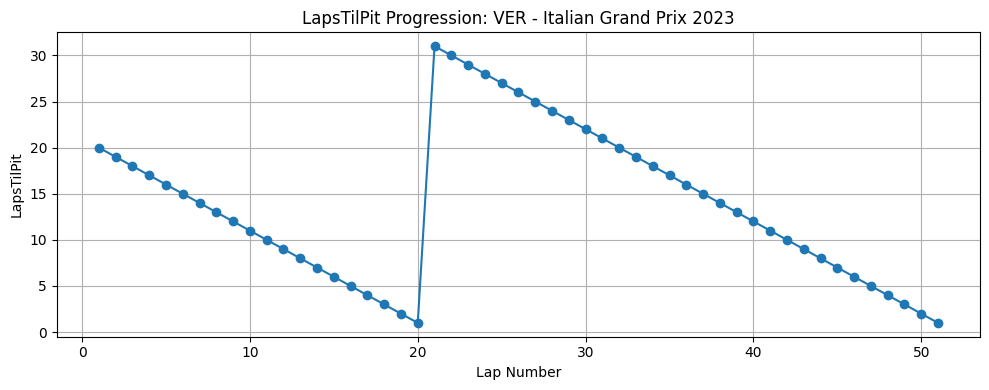

In [48]:
driver = 'VER'
race = 'Italian Grand Prix'
year = 2023

mask = (labelled_df['Driver'] == driver) & (labelled_df['Race'] == race) & (labelled_df['Year'] == year)
driver_race_df = labelled_df[mask].sort_values(['Stint', 'LapNumber'])

plt.figure(figsize=(10, 4))
plt.plot(driver_race_df['LapNumber'], driver_race_df['LapsTilPit'], marker='o')
plt.xlabel('Lap Number')
plt.ylabel('LapsTilPit')
plt.title(f'LapsTilPit Progression: {driver} - {race} {year}')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Remove Nulls

In [49]:
labelled_df.shape

(83517, 39)

In [50]:
labelled_df.isnull().sum()

Driver                    0
Team                      0
Year                      0
Race                      0
Sector1Time            1769
Sector2Time             154
Sector3Time             266
Sector1SessionTime     1957
Sector2SessionTime      154
Sector3SessionTime      266
SpeedI1               12743
SpeedI2                 174
SpeedFL                3098
Stint                     0
LapTime                1316
LapNumber                 0
Position                120
Compound                  0
TyreLife                  0
FreshTyre                 0
TrackStatus               0
AirTemp                   9
Humidity                  9
Pressure                  9
Rainfall                  9
TrackTemp                 9
WindDirection             9
WindSpeed                 9
Speed_Mean                0
Speed_Max                 0
Speed_Std                 0
RPM_Mean                  0
Throttle_Mean             0
Throttle_Std              0
Brake_Mean                0
Gear_Mean           

In [51]:
df_clean = labelled_df.dropna(subset=['LapTime'])

print(f"Shape before: {labelled_df.shape}")
print(f"Shape after:  {df_clean.shape}")

Shape before: (83517, 39)
Shape after:  (82201, 39)


In [52]:
df_clean.isnull().sum()

Driver                    0
Team                      0
Year                      0
Race                      0
Sector1Time            1503
Sector2Time              24
Sector3Time              37
Sector1SessionTime     1691
Sector2SessionTime       24
Sector3SessionTime       37
SpeedI1               12611
SpeedI2                  46
SpeedFL                2729
Stint                     0
LapTime                   0
LapNumber                 0
Position                  0
Compound                  0
TyreLife                  0
FreshTyre                 0
TrackStatus               0
AirTemp                   0
Humidity                  0
Pressure                  0
Rainfall                  0
TrackTemp                 0
WindDirection             0
WindSpeed                 0
Speed_Mean                0
Speed_Max                 0
Speed_Std                 0
RPM_Mean                  0
Throttle_Mean             0
Throttle_Std              0
Brake_Mean                0
Gear_Mean           

In [53]:
# Save labelled and cleaned data to CSV
df_clean.to_csv('data/f1_laps_clean.csv', index=False)